# Scenario 4 – Stacking

## Importing the Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

## Loading the Dataset

In [2]:
df = pd.read_csv('/content/heart_stacking.csv')

## Training the Model

In [4]:
target_col = 'HeartDisease'

X = df.drop(target_col, axis=1)
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [5]:
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
svm = SVC(probability=True)

## Using Stack Classifier

In [6]:
stack = StackingClassifier(
    estimators=[('lr', lr), ('dt', dt), ('svm', svm)],
    final_estimator=LogisticRegression()
)
stack.fit(X_train, y_train)

StackingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000)),
                               ('dt', DecisionTreeClassifier()),
                               ('svm', SVC(probability=True))],
                   final_estimator=LogisticRegression())

## Comparing with Individual Models

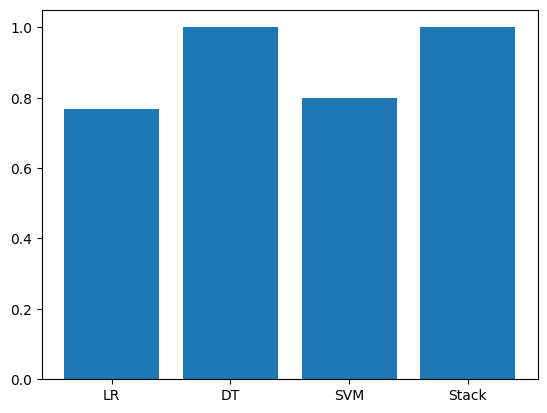

In [7]:
models = [lr, dt, svm, stack]
names = ['LR','DT','SVM','Stack']
acc=[]
for m in models:
    m.fit(X_train,y_train)
    acc.append(accuracy_score(y_test, m.predict(X_test)))
plt.bar(names, acc)
plt.show()